# Vadállat klasszifikációs neural network


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import ConvNeXtBase
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import BackupAndRestore, ModelCheckpoint, EarlyStopping, TensorBoard
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib
import datetime

## Adat konfiguráció

In [3]:
data_dir = pathlib.Path("/home/bogol/dataset/gbif_images_genus")
batch_size = 64
image_size = (384, 384)
epochs = 10
checkpoint_dir = "training_checkpoints"
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

## 2. Dataset betöltése és splitelése
70% / 15% / 15% felosztás Training, Validation és Testing.

In [4]:
print("Loading dataset...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

val_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.skip(val_batches // 2)
test_ds = val_test_ds.take(val_batches // 2)

print(f"Training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds)}")

Loading dataset...
Found 170001 files belonging to 354 classes.
Using 119001 files for training.


I0000 00:00:1780329612.639342   21957 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9704 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 170001 files belonging to 354 classes.
Using 51000 files for validation.
Found 354 classes: ['Abramis', 'Acanthis', 'Accipiter', 'Acrocephalus', 'Actitis', 'Aegithalos', 'Aegolius', 'Aegypius', 'Aix', 'Alauda', 'Alburnoides', 'Alburnus', 'Alca', 'Alcedo', 'Alces', 'Alle', 'Alopochen', 'Ameiurus', 'Ammodytes', 'Anas', 'Anguilla', 'Anguis', 'Anser', 'Anthus', 'Apodemus', 'Apus', 'Aquila', 'Ardea', 'Ardeola', 'Arenaria', 'Arvicola', 'Asio', 'Athene', 'Aythya', 'Babka', 'Ballerus', 'Barbastella', 'Barbatula', 'Barbus', 'Belone', 'Bison', 'Blicca', 'Bombina', 'Bombycilla', 'Bos', 'Botaurus', 'Branta', 'Bubulcus', 'Bucephala', 'Bufo', 'Bufotes', 'Buteo', 'Cairina', 'Calandrella', 'Calcarius', 'Calidris', 'Callonetta', 'Canis', 'Capra', 'Capreolus', 'Caprimulgus', 'Carassius', 'Carduelis', 'Carpodacus', 'Castor', 'Cepphus', 'Certhia', 'Cervus', 'Charadrius', 'Chenonetta', 'Chionomys', 'Chlidonias', 'Chloris', 'Chondrostoma', 'Chroicocephalus', 'Ciconia', 'Cinclus', 'Circaetus', 'Circus'

## 3. Tréning adat vizualizáció

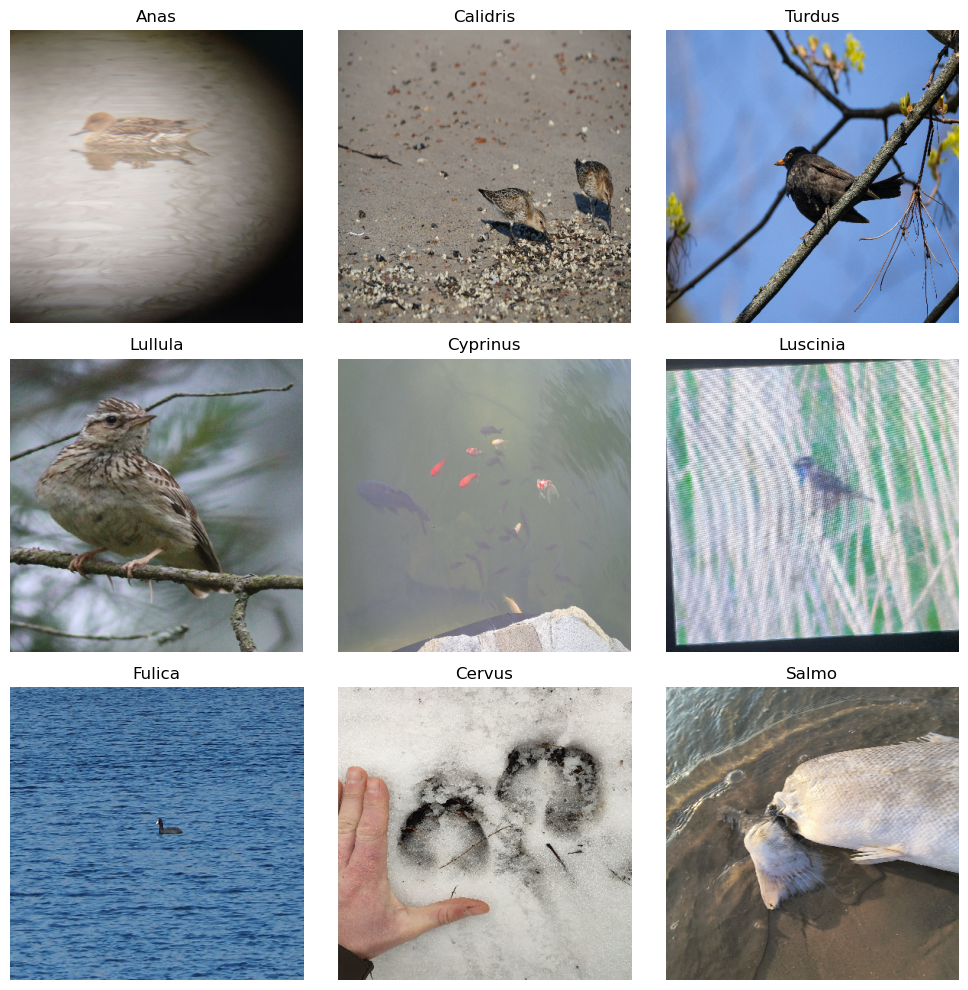

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

### Dataset optimalizálása
prefetch alkalmazása, hogy elkerüljük a bottleneck-eket adatok betöltésekor

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

## 4. Model megszerkesztése
ConvNeXtBase előre tanított modell alkalmazása backbone-ként. Backbone layerek fagyasztása, hogy csak az új fejet tanítsuk a datasetem

In [7]:
print("Building model...")
base_model = ConvNeXtBase(
    weights='imagenet',
    include_top=False,
    input_shape=image_size + (3,)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Building model...


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_pres… │ (None, 384, 384,  │          0 │ input_layer[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stem  │ (None, 96, 96,    │      6,528 │ convnext_base_pr… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │      6,400 │ convnext_base_st… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │        128 │ convnext_base_st… │
│ (LayerScale)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │          0 │ convnext_base_st… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96,    │          0 │ convnext_base_st… │
│                     │ 128)              │            │ convnext_base_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │      6,400 │ add[0][0]         │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 96, 96,    │        128 │ convnext_base_st

 Total params: 87,929,314 (335.42 MB)

 Trainable params: 362,850 (1.38 MB)

 Non-trainable params: 87,566,464 (334.04 MB)

## 5. Modell betanítása
check-pointok létrehozása

In [8]:
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=False,
    update_freq='epoch',
    profile_batch=0
)

In [9]:
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

backup_callback = BackupAndRestore(backup_dir=os.path.join(checkpoint_dir, 'backup'))

checkpoint_callback = ModelCheckpoint(
    filepath="wildlife_classifier_best.keras",
    save_best_only=True,
    monitor='val_loss',
    mode='min'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


print(f"TensorBoard logs will be saved to: {log_dir}")
print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[backup_callback, checkpoint_callback, early_stopping, tensorboard_callback]
)

TensorBoard logs will be saved to: logs/fit/20260601-180002
Starting training...
Epoch 1/50


I0000 00:00:1780329665.712554   22024 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1860/1860 ━━━━━━━━━━━━━━━━━━━━ 1993s 1s/step - accuracy: 0.2882 - loss: 3.6082 - val_accuracy: 0.5072 - val_loss: 2.4640
Epoch 2/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 1908s 1s/step - accuracy: 0.5187 - loss: 2.2468 - val_accuracy: 0.5994 - val_loss: 1.8810
Epoch 3/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 1904s 1s/step - accuracy: 0.5881 - loss: 1.8376 - val_accuracy: 0.6411 - val_loss: 1.6161
Epoch 4/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 1909s 1s/step - accuracy: 0.6225 - loss: 1.6244 - val_accuracy: 0.6672 - val_loss: 1.4605
Epoch 5/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 1902s 1s/step - accuracy: 0.6460 - loss: 1.4919 - val_accuracy: 0.6841 - val_loss: 1.3600
Epoch 6/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 1911s 1s/step - accuracy: 0.6603 - loss: 1.4038 - val_accuracy: 0.6968 - val_loss: 1.2865
Epoch 7/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 1904s 1s/step - accuracy: 0.6713 - loss: 1.3361 - val_accuracy: 0.7044 - val_loss: 1.2312
Epoch 8/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 1950s 1s/step - accuracy: 0.6821 - loss: 1.28

In [17]:
batch_size_fine = 16  # vagy 8, ha még mindig OOM

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size_fine,
)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size_fine,
)

val_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.skip(val_batches // 2)
test_ds = val_test_ds.take(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 170001 files belonging to 354 classes.
Using 119001 files for training.
Found 170001 files belonging to 354 classes.
Using 51000 files for validation.


In [11]:
# Ezt a cellát összevontuk a következővel az automatikus javítás során.


In [ ]:
model = tf.keras.models.load_model("wildlife_classifier_best.keras")
print("Best model loaded successfully!")

# Bázismodell feloldása a finomhangoláshoz
# (Mivel újra betöltöttük, érdemes a név alapján hivatkozni rá, vagy feltételezve, hogy ConvNeXt)
base_model = model.layers[1] if hasattr(model.layers[1], 'layers') else [l for l in model.layers if hasattr(l, 'layers')][0]
base_model.trainable = True



for layer in base_model.layers[:75]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

finetune_backup = BackupAndRestore(backup_dir=os.path.join(checkpoint_dir, 'backup_finetune'))

finetune_checkpoint = ModelCheckpoint(
    filepath="wildlife_classifier_finetuned_best.keras",
    save_best_only=True,
    monitor='val_loss',
    mode='min'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)



print("Starting fine-tuning...")
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[finetune_backup, finetune_checkpoint, early_stopping, tensorboard_callback]
)


NameError: name 'tf' is not defined

In [13]:
#model = tf.keras.models.load_model("wildlife_classifier_best.keras")
#print("Best model loaded successfully!")

In [14]:
#model = tf.keras.models.load_model("wildlife_classifier_finetuned_best.keras")
#print("Best model loaded successfully!")

## 6. tanulási adatok kiértékelése

In [20]:

%load_ext tensorboard
%tensorboard --logdir logs/fit

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 56580), started 1:11:25 ago. (Use '!kill 56580' to kill it.)

In [16]:
# Összefűzzük a két fázis listáit
if 'history_finetune' in locals():
    acc = history.history['accuracy'] + history_finetune.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']
    loss = history.history['loss'] + history_finetune.history['loss']
    val_loss = history.history['val_loss'] + history_finetune.history['val_loss']
else:
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(acc, label='Training Accuracy')
axes[0].plot(val_acc, label='Validation Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(loss, label='Training Loss')
axes[1].plot(val_loss, label='Validation Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


KeyError: 'accuracy'

## 7. Test set kiértékelése és végső modell mentése

In [ ]:
print("Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

model.save("wildlife_classifier_final.keras")
print("Final model saved as 'wildlife_classifier_final.keras'")

Evaluating on test set...
797/797 ━━━━━━━━━━━━━━━━━━━━ 128s 142ms/step - accuracy: 0.7096 - loss: 1.0874
Test accuracy: 0.7096, Test loss: 1.0874
Final model saved as 'wildlife_classifier_final.keras'


In [ ]:
image_path = "vaddiszno.jpg"
target_size = (384, 384)
if os.path.exists(image_path):

    img = tf.keras.utils.load_img(image_path, target_size=target_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)
    score = predictions[0]
    class_idx = np.argmax(score)
    predicted_label = class_names[class_idx]
    confidence = 100 * score[class_idx]

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()
else:
    print(f"Error: File '{image_path}' not found in the current folder.")

Error: File 'vaddiszno.jpg' not found in the current folder.
